# Combining Data and Model testing

### Imports

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier

y_train_path = "./widsdatathon2025/TRAIN_NEW/TRAINING_SOLUTIONS.xlsx"



### Import Data

In [38]:
qm_df = pd.read_csv('./qm_df.csv')
qm_df.set_index('Unnamed: 0', inplace=True)
qm_FS_df = pd.read_csv('./qm_FS_df.csv')
cm_df = pd.read_csv('./cm_df.csv')
cm_dummies_df = pd.read_csv('./cm_dummies_df.csv')


fmri_train_pca_df = pd.read_csv('./train_connectome_PCA.csv')
fmri_train_tsne_df = pd.read_csv('./train_connectome_tSNE.csv')


y = pd.read_excel(y_train_path)



### Combine Data

In [39]:
print(qm_df.shape)
print(y.shape)
print(cm_dummies_df.shape)
print(fmri_train_pca_df.shape)
print(fmri_train_tsne_df.shape)

y_indices_overflow = y.index.difference(qm_df.index)
y = y.loc[~y.index.isin(y_indices_overflow)]

"""
cm_indices_overflow = cm_df.index.difference(qm_df.index)
cm_df = cm_df.loc[~cm_df.index.isin(cm_indices_overflow)]
"""


cm_dummies_indices_overflow = cm_dummies_df.index.difference(qm_df.index)
cm_dummies_df = cm_dummies_df.loc[~cm_dummies_df.index.isin(cm_dummies_indices_overflow)]

fmri_pca_overflow = fmri_train_pca_df.index.difference(qm_df.index)
fmri_train_pca_df = fmri_train_pca_df.loc[~fmri_train_pca_df.index.isin(fmri_pca_overflow)]

fmri_tsne_overflow = fmri_train_tsne_df.index.difference(qm_df.index)
fmri_train_tsne_df = fmri_train_tsne_df.loc[~fmri_train_tsne_df.index.isin(fmri_tsne_overflow)]


print("MATCHED INDICIES: ")
print(qm_df.shape)
print(y.shape)
print(cm_dummies_df.shape)
print(fmri_train_pca_df.shape)
print(fmri_train_tsne_df.shape)

(1192, 15)
(1213, 3)
(1213, 57)
(1213, 2)
(1213, 2)
MATCHED INDICIES: 
(1192, 15)
(1192, 3)
(1192, 57)
(1192, 2)
(1192, 2)


In [ ]:
# CM Feature drop

cm_dummies_df = cm_dummies_df.drop(columns=["p2_occ_cat2", "P2_occ_cat9", "race_Black/African American", "p1_education_7th or less", "p1_occ_cat2", "conduct_problems", "scan_site_Staten Island", "p2_occ_stay at home", "p1_education_Partial college", "race_Asian", "p2_education_HS graduate", "involvement", "p2_occ_cat8", "p2_education_HS graduate"])


In [40]:

pca_df = pd.concat([qm_df,
                cm_dummies_df,
                fmri_train_pca_df
                ], axis=1)

tsne_df = pd.concat([qm_df,
                cm_dummies_df,
                fmri_train_tsne_df
                ], axis=1)

if "Unnamed: 0" in pca_df.columns:
    pca_df = pca_df.drop(columns=["Unnamed: 0"])

if "Unnamed: 0" in tsne_df.columns:
    tsne_df = tsne_df.drop(columns=["Unnamed: 0"])




### Find Adequate models

In [52]:
models = {
    'Logistic Regression': {
        'model': LogisticRegression(),
        'params': {
            'model__C': [0.001, 0.01, 0.1, 1, 5, 10, 15, 20],

            'model__penalty': ['l1', 'l2', 'elasticnet'],

            'model__multi_class': ['auto', 'ovr', 'multinomial']
        }
    },
    'SVM': {
        'model': SVC(),
        'params': {
            'model__C': [0.01, 0.1, 1, 3, 5, 10, 20],

            'model__gamma': ['scale', 'auto'],

            'model__kernel': ['rbf', 'linear', 'poly', 'sigmoid'],

        }
    },
    'Naive Bayes': {
        'model': GaussianNB(),
        'params': {}
    },


    'XGBoost': {
        'model': XGBClassifier(use_label_encoder=True, eval_metric='logloss'),
        'params': {
            'model__n_estimators': [50, 100, 200, 300, 500],

            'model__max_depth': [3, 5, 7, 9, 11, 15],

            'model__learning_rate': [0.01, 0.05, 0.1, 0.2, 0.3],

            'model__scale_pos_weight': [1, 2, 5]
        }
    }
}


def optimize_models(data_dict, model_list, y_data):
    all_results = []
    test_results = []

    for dataset_name, dataset in data_dict.items():
        print(f"Processing {dataset_name}...")



        X_train, X_test, y_train, y_test = train_test_split(dataset, y_data, test_size=0.3)


        dataset_results = []
        best_models = {}

        for model_name, config in model_list.items():
            print(f"Training {model_name}...")
            pipeline = Pipeline([
                ('scaler', StandardScaler()),
                ('model', config['model'])
            ])

            grid = GridSearchCV(pipeline, config['params'], cv=4, scoring='accuracy', n_jobs=-1)
            grid.fit(X_train, y_train)

            best_models[model_name] = grid.best_estimator_
            dataset_results.append({
                'Dataset': dataset_name,
                'Model': model_name,
                'Best Params': grid.best_params_,
                'CV Accuracy': grid.best_score_
            })

        for model_name, model in best_models.items():
            y_pred = model.predict(X_test)
            test_accuracy = accuracy_score(y_test, y_pred)
            test_results.append({
                'Test Accuracy': test_accuracy
            })

        all_results.extend(dataset_results)

    cv_results_df = pd.DataFrame(all_results)
    test_results_df = pd.DataFrame(test_results)

    return  pd.concat([cv_results_df, test_results_df], axis=1)


In [47]:

#Predict ADHD and add to DF1 to help sex prediction outcome.
#Parameters found via above code run only on y["ADHD_Outcome"] which gives about 98% confidence
#adhd_model = SVC(C=0.01, gamma='scale', kernel='linear', probability=True)
#adhd_model = XGBClassifier(learning_rate=0.01, max_depth=7, n_estimators=100)

#adhd_model.fit(tsne_df, y["ADHD_Outcome"])


#adhd_pred = adhd_model.predict_proba(tsne_df)[:,1]

#Add ADHD outcome to input data to help performance
#df2 = tsne_df.copy()
#df2["ADHD_Pred"] = adhd_pred

In [53]:
dataset_dictionary2 = { #Run on both datasets to see difference in performance
                        "df": pca_df,
                        "df1": tsne_df,
}

results = optimize_models(dataset_dictionary2, models, y["ADHD_Outcome"])


Processing df...
Training Logistic Regression...


C:\Users\patri\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py:540: FitFailedWarning: 
192 fits failed out of a total of 288.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
96 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\patri\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py", line 888, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "C:\Users\patri\anaconda3\Lib\site-packages\sklearn\base.py", line 1473, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\patri\anaconda3\Lib\site-packages\sklearn\pipeline.py", line 473, in fit
    self._final_estimator.f

Training SVM...
Training Naive Bayes...
Training XGBoost...


C:\Users\patri\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [22:00:57] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Processing df1...
Training Logistic Regression...


C:\Users\patri\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py:540: FitFailedWarning: 
192 fits failed out of a total of 288.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
96 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\patri\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py", line 888, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "C:\Users\patri\anaconda3\Lib\site-packages\sklearn\base.py", line 1473, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\patri\anaconda3\Lib\site-packages\sklearn\pipeline.py", line 473, in fit
    self._final_estimator.f

Training SVM...
Training Naive Bayes...
Training XGBoost...


C:\Users\patri\anaconda3\Lib\site-packages\numpy\ma\core.py:2820: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,
C:\Users\patri\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [22:01:09] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [54]:
results

,Dataset,Model,Best Params,CV Accuracy,Test Accuracy
0,df,Logistic Regression,"{'model__C': 0.001, 'model__multi_class': 'aut...",0.683451,0.692737
1,df,SVM,"{'model__C': 1, 'model__gamma': 'scale', 'mode...",0.688236,0.695531
2,df,Naive Bayes,{},0.478452,0.441341
3,df,XGBoost,"{'model__learning_rate': 0.01, 'model__max_dep...",0.684659,0.675978
4,df1,Logistic Regression,"{'model__C': 0.001, 'model__multi_class': 'aut...",0.691848,0.673184
5,df1,SVM,"{'model__C': 0.01, 'model__gamma': 'scale', 'm...",0.691848,0.673184
6,df1,Naive Bayes,{},0.431485,0.379888
7,df1,XGBoost,"{'model__learning_rate': 0.01, 'model__max_dep...",0.693050,0.673184


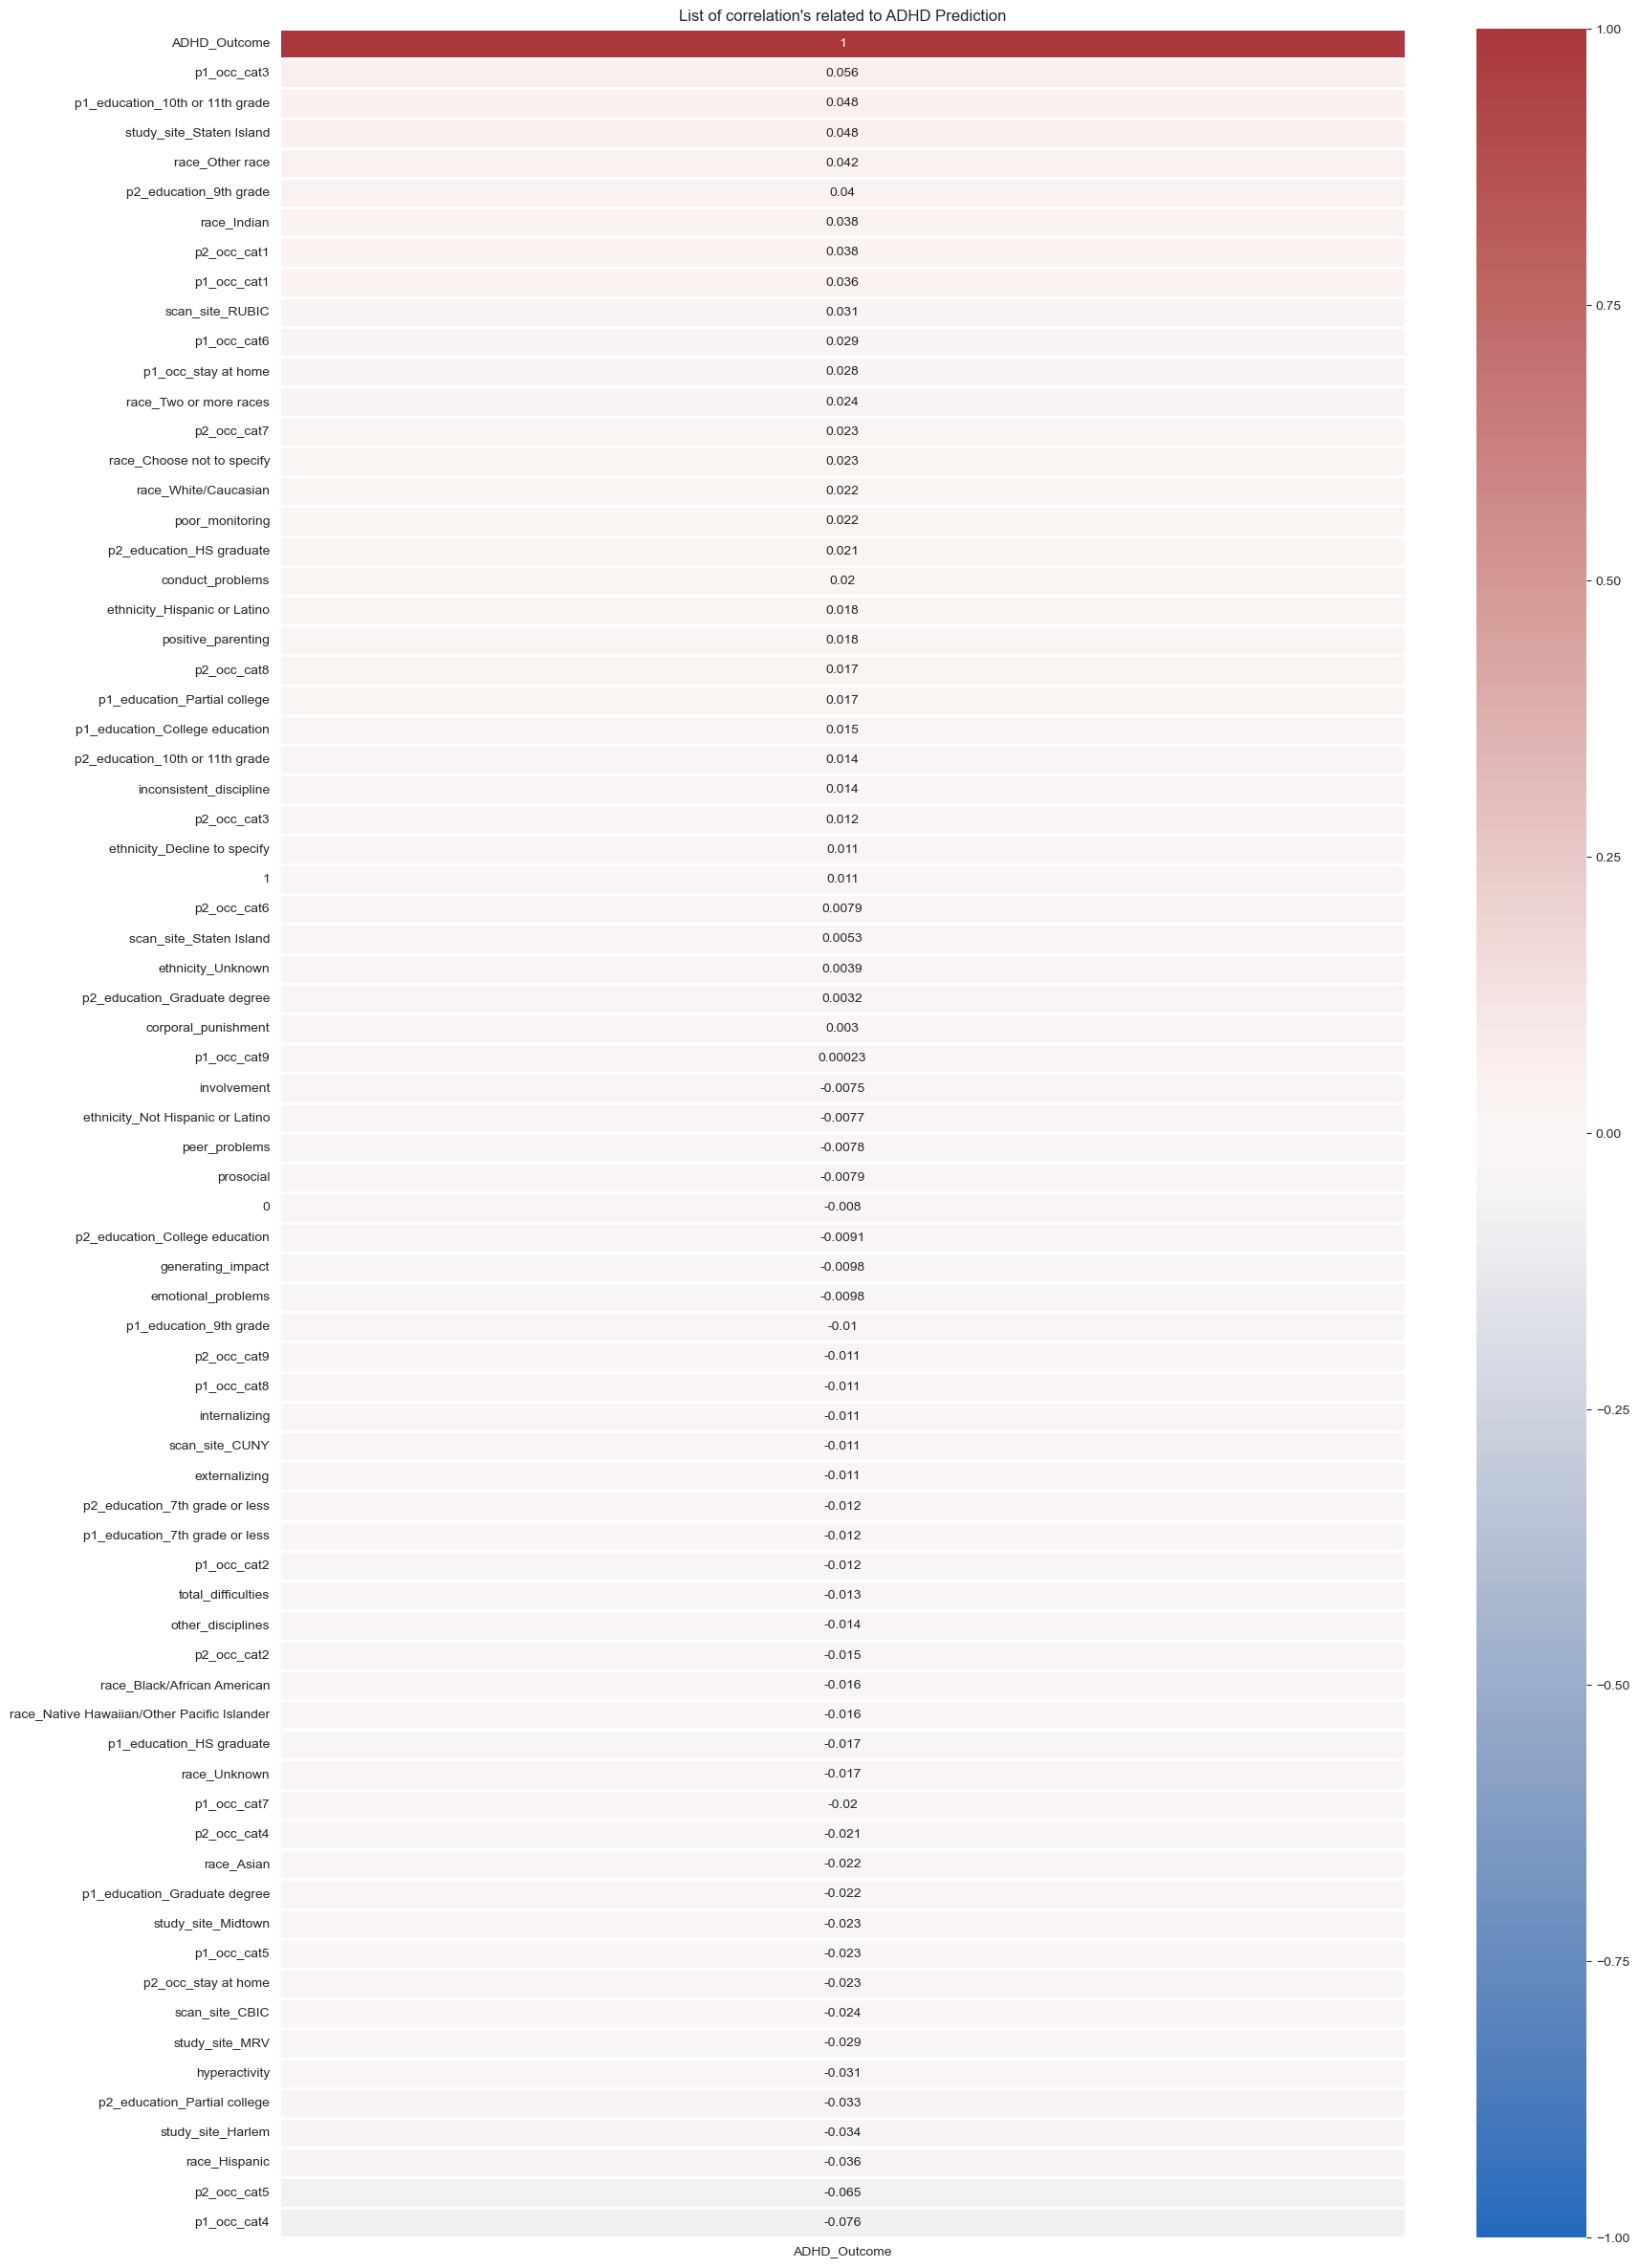

In [50]:
import matplotlib.pyplot as plt
import seaborn as sns
corr_matrix = pd.concat([tsne_df, y["ADHD_Outcome"]], axis = 1).corr()

fig, ax = plt.subplots( figsize = (19, 30))
sns.set_style("whitegrid")
heat = sns.heatmap(corr_matrix[["ADHD_Outcome"]].sort_values(by='ADHD_Outcome', ascending=False), linewidth=1,annot=True, cmap = 'vlag', vmin=-1)
plt.title("List of correlation's related to ADHD Prediction")
plt.show()

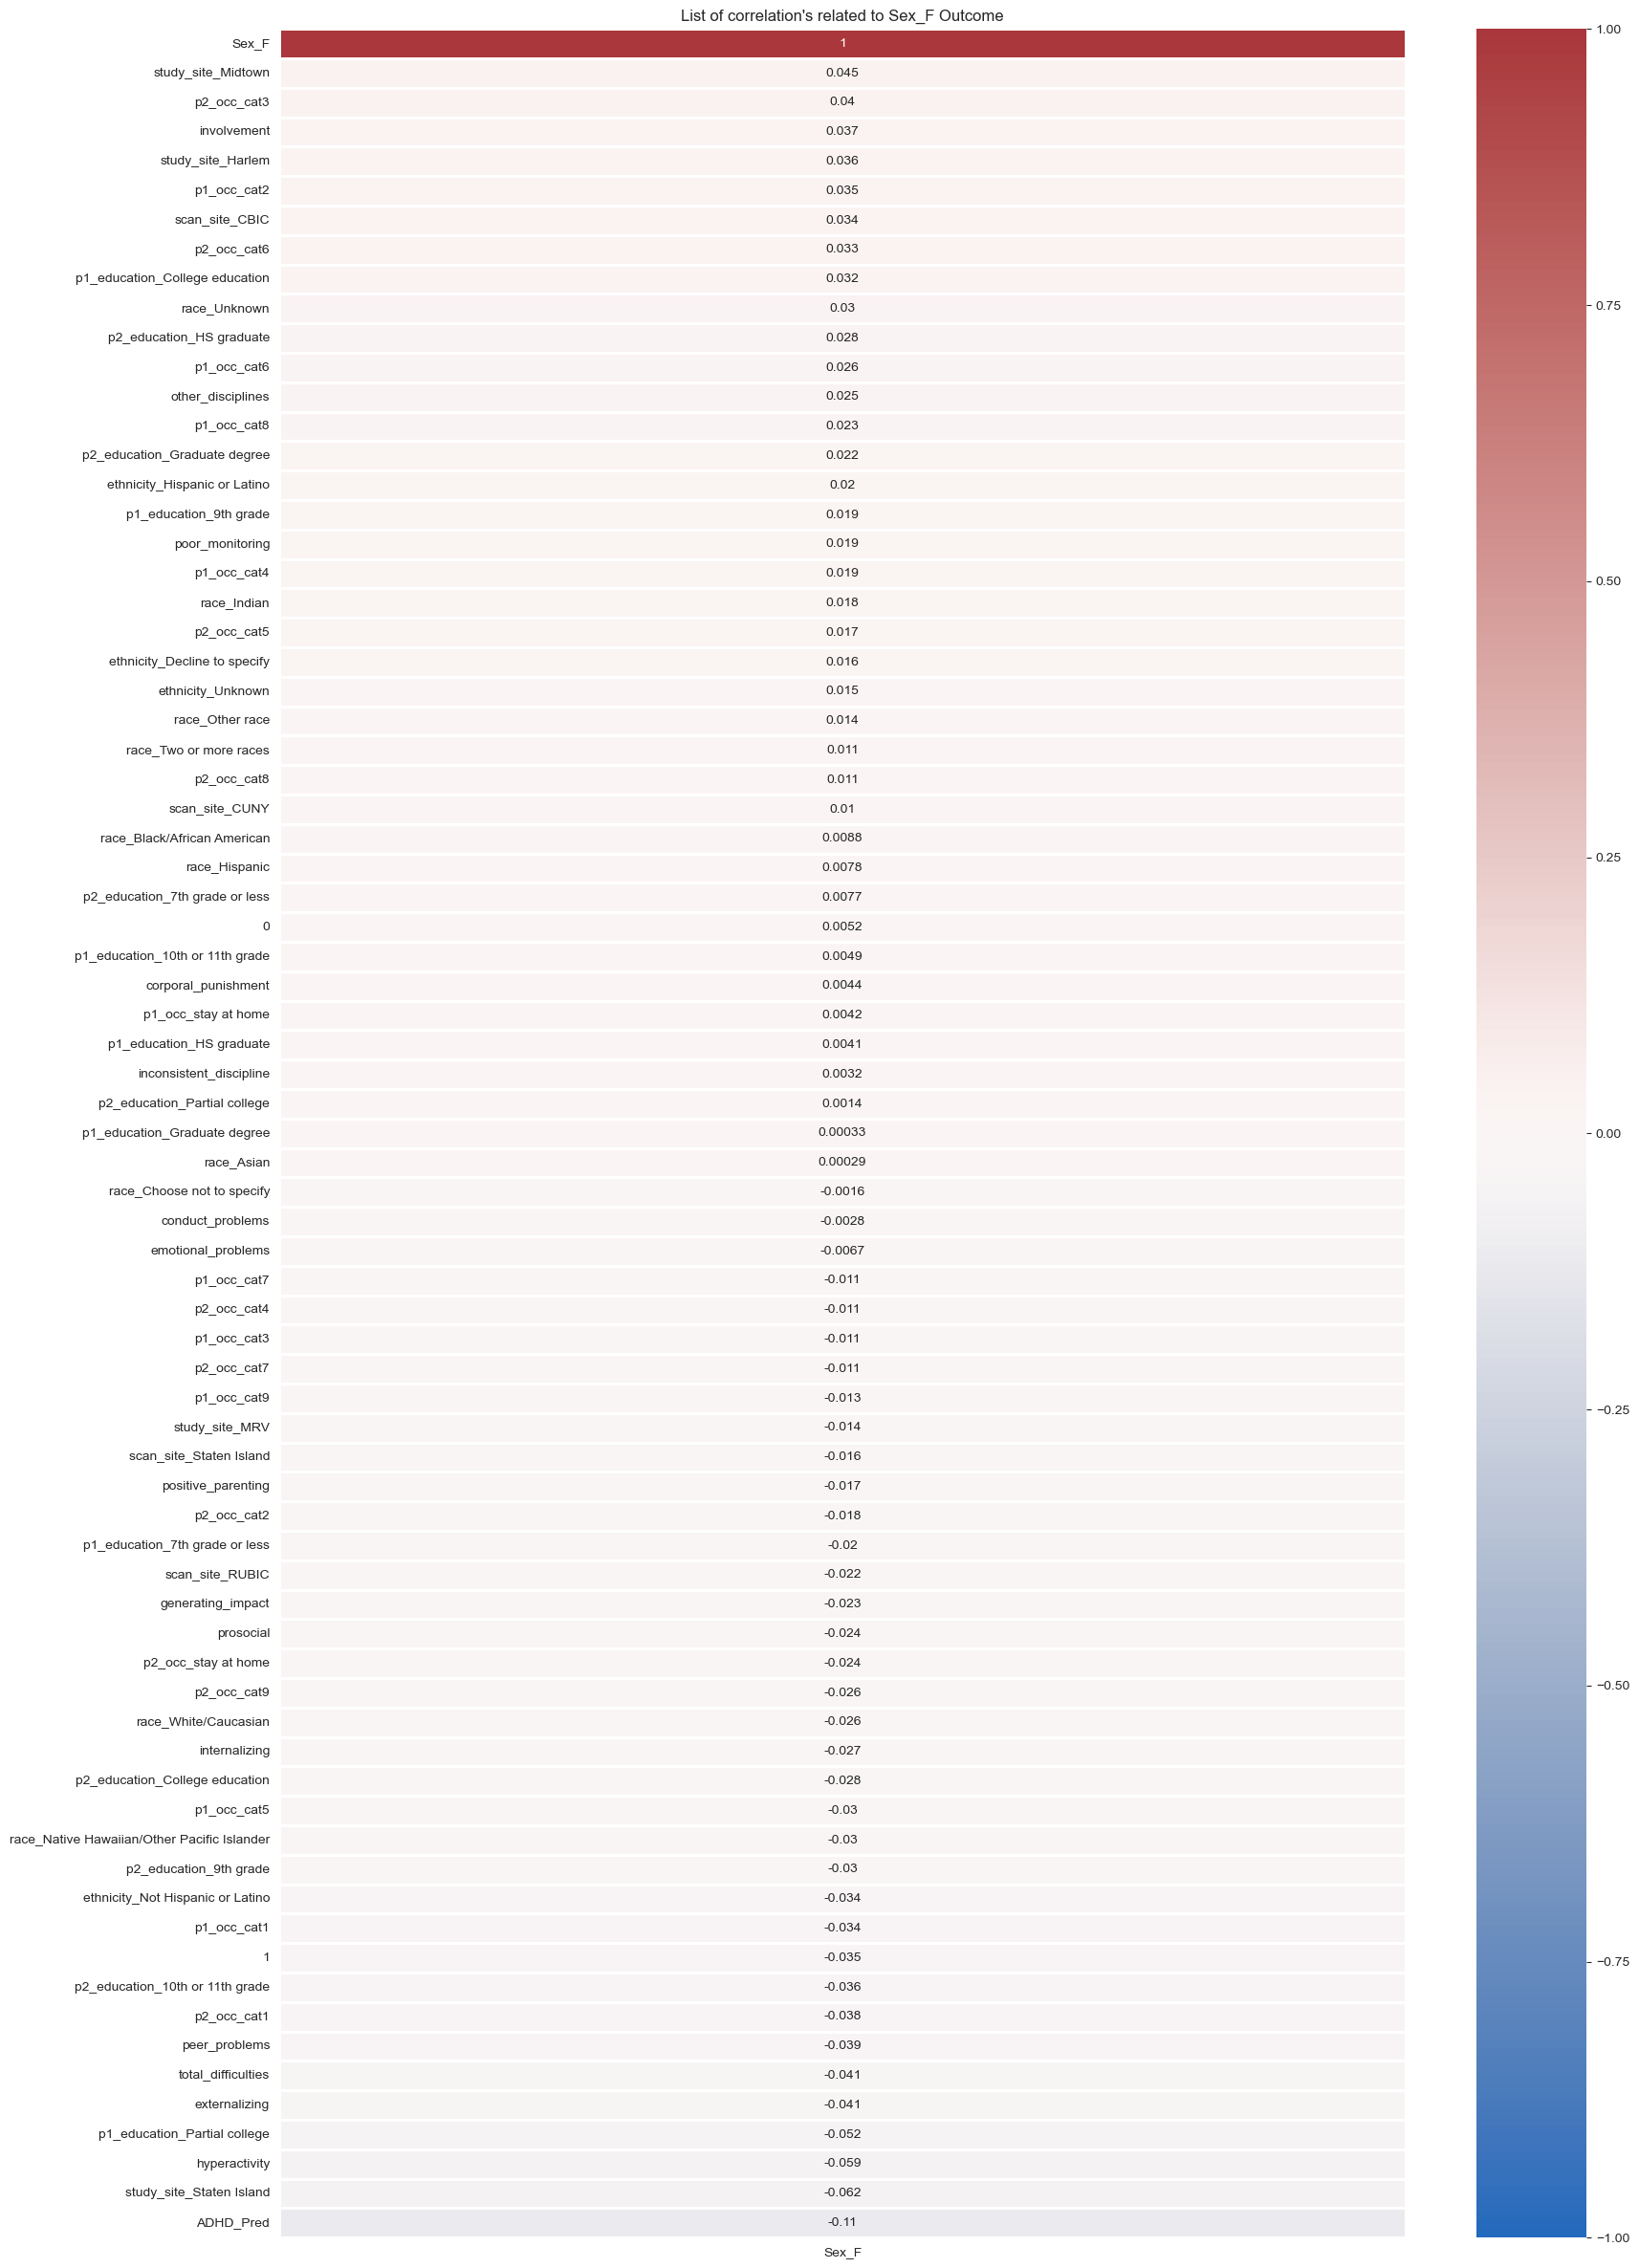

In [55]:
import matplotlib.pyplot as plt
import seaborn as sns
corr_matrix = pd.concat([df2, y["Sex_F"]], axis = 1).corr()

fig, ax = plt.subplots( figsize = (19, 30))
sns.set_style("whitegrid")
heat = sns.heatmap(corr_matrix[["Sex_F"]].sort_values(by='Sex_F', ascending=False), linewidth=1,annot=True, cmap = 'vlag', vmin=-1)
plt.title("List of correlation's related to Sex_F Outcome")
plt.show()